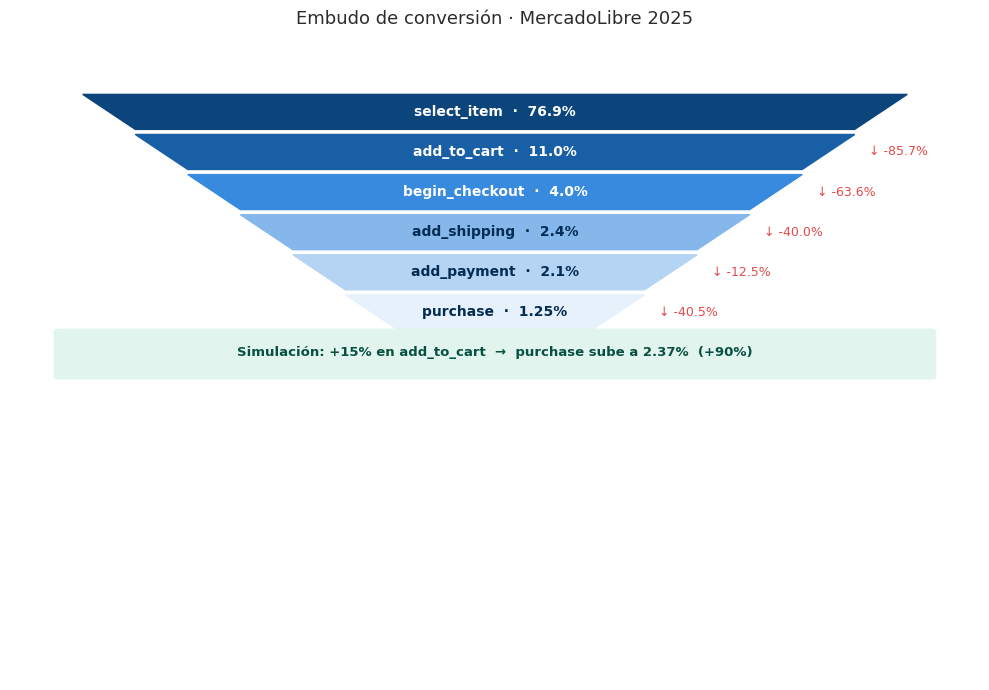

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

etapas = [
    ('select_item',    76.9, None),
    ('add_to_cart',    11.0, '-85.7%'),
    ('begin_checkout',  4.0, '-63.6%'),
    ('add_shipping',    2.4, '-40.0%'),
    ('add_payment',     2.1, '-12.5%'),
    ('purchase',        1.25,'-40.5%'),
]

colores = ['#0C447C','#185FA5','#378ADD','#85B7EB','#B5D4F4','#E6F1FB']
texto_color = ['white','white','white','#042C53','#042C53','#042C53']

n = len(etapas)
alto = 0.55
gap = 0.08
y_start = 9.2

# ancho máximo y mínimo del embudo
w_max = 8.5
w_min = 2.0
centro = 5.0

for i, (nombre, pct, drop) in enumerate(etapas):
    w_top = w_max - (w_max - w_min) * (i / n)
    w_bot = w_max - (w_max - w_min) * ((i + 1) / n)
    y_top = y_start - i * (alto + gap)
    y_bot = y_top - alto

    x_top_l = centro - w_top / 2
    x_top_r = centro + w_top / 2
    x_bot_l = centro - w_bot / 2
    x_bot_r = centro + w_bot / 2

    trapecio = plt.Polygon(
        [[x_top_l, y_top],[x_top_r, y_top],
         [x_bot_r, y_bot],[x_bot_l, y_bot]],
        closed=True, color=colores[i]
    )
    ax.add_patch(trapecio)

    # etiqueta dentro del trapecio
    ax.text(centro, (y_top + y_bot) / 2,
            f'{nombre}  ·  {pct}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color=texto_color[i])

    # drop-off a la derecha
    if drop:
        ax.text(centro + w_top / 2 + 0.15,
                y_top - alto / 2,
                f'↓ {drop}',
                ha='left', va='center',
                fontsize=9, color='#E24B4A')

# caja simulación al fondo
sim_y = y_start - n * (alto + gap) - 0.1
rect = patches.FancyBboxPatch((0.5, sim_y - 0.55), 9, 0.7,
    boxstyle="round,pad=0.05", linewidth=0,
    facecolor='#E1F5EE')
ax.add_patch(rect)
ax.text(centro, sim_y - 0.18,
        'Simulación: +15% en add_to_cart  →  purchase sube a 2.37%  (+90%)',
        ha='center', va='center', fontsize=9.5,
        color='#085041', fontweight='bold')

plt.title('Embudo de conversión · MercadoLibre 2025',
          fontsize=13, pad=14, color='#2C2C2A')
plt.tight_layout()
plt.savefig("funnel_mercadolibre.png", dpi=150, bbox_inches="tight")
plt.show()